In [1]:
pip install kmodes

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
from kmodes.kmodes import KModes
import matplotlib.pyplot as plt


In [5]:
# contoh data artifisial
import numpy as np

data = np.array([
    ['A', 'B', 'C'],
    ['B', 'C', 'A'],
    ['C', 'A', 'B'],
    ['A', 'C', 'B'],
    ['A', 'A', 'B']
])


Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 0, cost: 7.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 2, iteration: 1/100, moves: 0, cost: 7.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 3, iteration: 1/100, moves: 0, cost: 7.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 4, iteration: 1/100, moves: 0, cost: 7.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 5, iteration: 1/100, moves: 0, cost: 7.0
Best run was number 1
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 1, cost: 4.0
Run 1, iteration: 2/100, moves: 0, cost: 4.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 2, iteration: 1/100, moves: 0, cost: 4.0
Init: initializing centroids
Init: initializing clusters
S

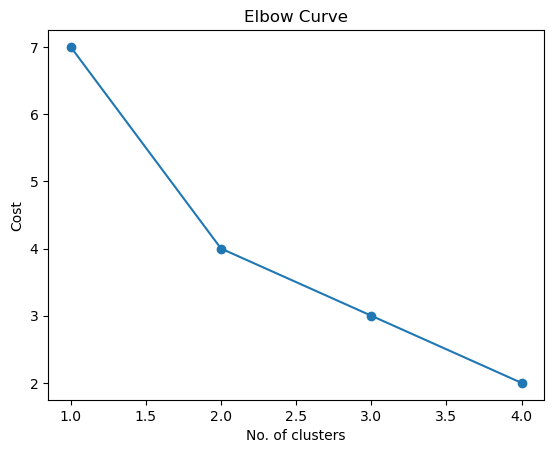

In [6]:
cost = []
K = range(1, 5)
for i in K:
    kmode = KModes(n_clusters=i, init="random", n_init=5, verbose=1)
    kmode.fit_predict(data)
    cost.append(kmode.cost_)
plt.plot(K, cost, marker='o')
plt.xlabel('No. of clusters')
plt.ylabel('Cost')
plt.title('Elbow Curve')
plt.show()

In [7]:
kmode = KModes(n_clusters=2, init = "random", n_init = 5, verbose=1)
clusters = kmode.fit_predict(data)
clusters

Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 0, cost: 4.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 2, iteration: 1/100, moves: 1, cost: 5.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 3, iteration: 1/100, moves: 0, cost: 5.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 4, iteration: 1/100, moves: 0, cost: 5.0
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 5, iteration: 1/100, moves: 0, cost: 4.0
Best run was number 1


array([0, 1, 0, 0, 0], dtype=uint16)

# TUGAS

In [29]:
import pandas as pd
import numpy as np
from kmodes.kmodes import KModes
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.decomposition import PCA

In [30]:
data_bank = pd.read_csv('C:/py data/bank-full.csv', sep=';', quotechar='"')

In [31]:
data_bank

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no


In [32]:
data_bank['age_bin'] = pd.cut(data_bank['age'], bins=[0,20,30,40,50,60,100],
                              labels=['<20','20-29','30-39','40-49','50-59','60+'])

In [33]:
data_bank['balance_bin'] = pd.qcut(data_bank['balance'].rank(method='first'), q=5,
                                   labels=['bal_vlow','bal_low','bal_mid','bal_high','bal_vhigh'])

In [34]:
data_bank['duration_bin'] = pd.qcut(data_bank['duration'].rank(method='first'), q=4,
                                    labels=['dur_short','dur_med','dur_long','dur_vlong'])

In [35]:
# Pilih kolom kategori saja
data = data_bank[['job','marital','education','default','housing','loan','contact',
                  'month','poutcome','age_bin','balance_bin','duration_bin']]

In [36]:
data = data.astype(str).to_numpy()

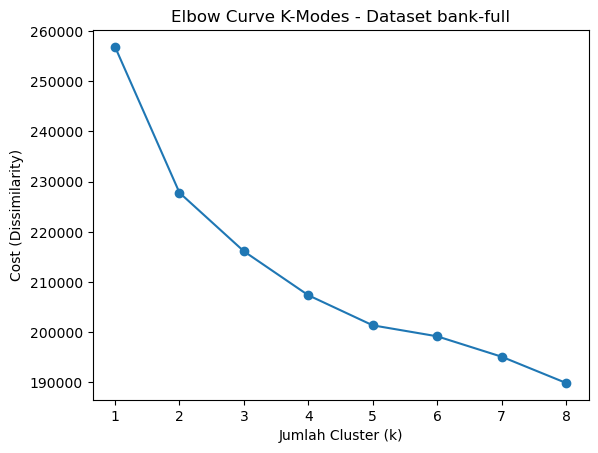

In [37]:
# Elbow Method untuk menentukan jumlah clustur yang optimal
cost = []
K = range(1, 9)

for i in K:
    kmode = KModes(n_clusters=i, init="Cao", n_init=5, verbose=0, random_state=42)
    kmode.fit_predict(data)
    cost.append(kmode.cost_)

plt.plot(K, cost, marker='o')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Cost (Dissimilarity)')
plt.title('Elbow Curve K-Modes - Dataset bank-full')
plt.show()

In [17]:
# menjalankan K-modes dengan jumlah cluster terbaik
kmode = KModes(n_clusters=4, init="Cao", n_init=10, verbose=1, random_state=42)
clusters = kmode.fit_predict(data)

Initialization method and algorithm are deterministic. Setting n_init to 1.
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 5790, cost: 207354.0


In [18]:
# menambahkan hasil cluster ke dataframe
data_bank['cluster'] = clusters
print(data_bank[['job','marital','education','housing','loan','cluster']].head(10))

            job   marital  education housing loan  cluster
0    management   married   tertiary     yes   no        2
1    technician    single  secondary     yes   no        1
2  entrepreneur   married  secondary     yes  yes        0
3   blue-collar   married    unknown     yes   no        0
4       unknown    single    unknown      no   no        0
5    management   married   tertiary     yes   no        1
6    management    single   tertiary     yes  yes        1
7  entrepreneur  divorced   tertiary     yes   no        0
8       retired   married    primary     yes   no        0
9    technician    single  secondary     yes   no        0


In [19]:
#Centroid (mode setiap cluster)
centroids = pd.DataFrame(kmode.cluster_centroids_,
                         columns=['job','marital','education','default','housing','loan',
                                  'contact','month','poutcome','age_bin','balance_bin','duration_bin'])
print(centroids)

           job  marital  education default housing loan   contact month  \
0  blue-collar  married  secondary      no     yes   no  cellular   may   
1   management   single   tertiary      no      no   no   unknown   jun   
2   management  married   tertiary      no      no   no  cellular   jul   
3   technician   single  secondary      no      no   no  cellular   aug   

  poutcome age_bin balance_bin duration_bin  
0  unknown   30-39    bal_vlow    dur_vlong  
1  unknown   40-49     bal_low      dur_med  
2  unknown   50-59    bal_high    dur_short  
3  unknown   20-29   bal_vhigh     dur_long  


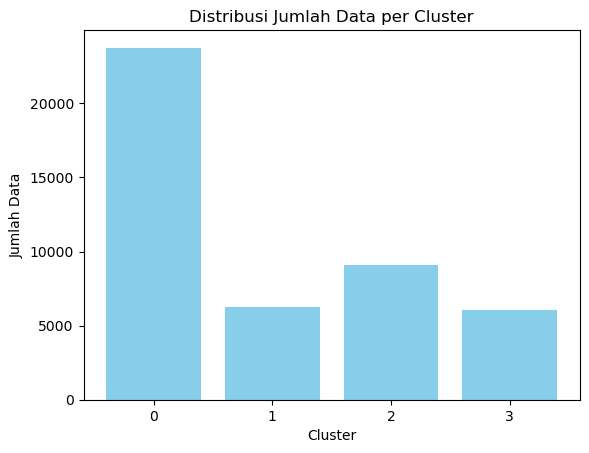

In [20]:
# Visualisasi
# --- Plot 1: Distribusi jumlah data per cluster
unique, counts = np.unique(clusters, return_counts=True)
plt.bar(unique.astype(str), counts, color='skyblue')
plt.xlabel('Cluster')
plt.ylabel('Jumlah Data')
plt.title('Distribusi Jumlah Data per Cluster')
plt.show()

In [25]:
# --- Plot 2: Visualisasi PCA 2D (penyebaran cluster)
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded = encoder.fit_transform(data_bank[['job','marital','education','default','housing','loan',
                                           'contact','month','poutcome','age_bin','balance_bin','duration_bin']])

pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(encoded)


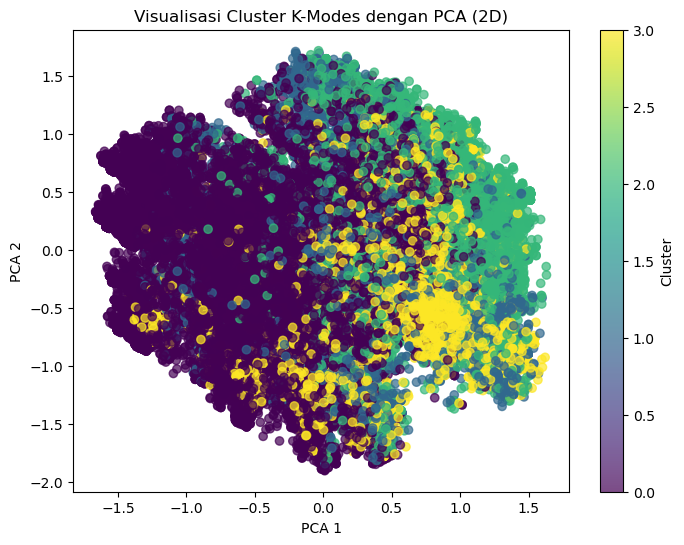

In [26]:
plt.figure(figsize=(8,6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], c=clusters, cmap='viridis', alpha=0.7)
plt.title('Visualisasi Cluster K-Modes dengan PCA (2D)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.colorbar(label='Cluster')
plt.show()

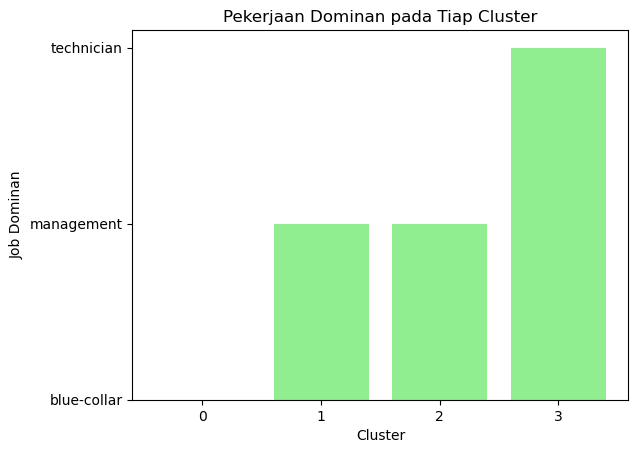

In [27]:
# --- Plot 3: Pekerjaan dominan di tiap cluster
job_dominan = data_bank.groupby('cluster')['job'].agg(lambda x: x.value_counts().index[0])
plt.bar(job_dominan.index.astype(str), job_dominan.values, color='lightgreen')
plt.xlabel('Cluster')
plt.ylabel('Job Dominan')
plt.title('Pekerjaan Dominan pada Tiap Cluster')
plt.show()